In [25]:
import networkx as nx
import matplotlib.pyplot as plt
import cvxpy as cp

In [26]:
depot: int = 0
schools: list[int] = [1, 2]
demands: dict[int, int] = {i: 1 for i in schools}

num_buses = 2
buses = list(range(num_buses))
Q = {k: 5 for k in buses}
R = {k: 20 for k in buses}

C:\Users\diego\AppData\Local\Temp\ipykernel_37688\4103280198.py:48: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


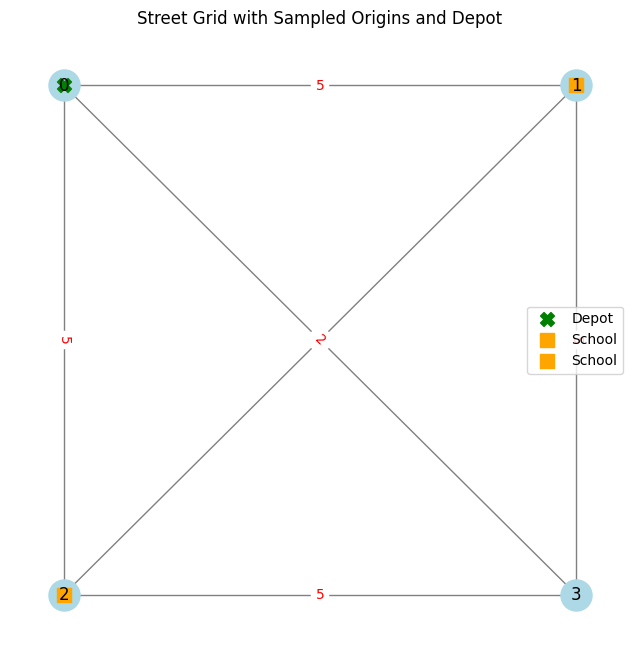

In [27]:
g = nx.Graph()
node_mapping = {}  # Map (row, col) to a unique integer
counter = 0

for i in range(2):
    for j in range(2):
        node_mapping[(i, j)] = counter
        counter += 1

for i in range(2):
    for j in range(2):
        if i > 0:
            g.add_edge(node_mapping[(i, j)], node_mapping[(i - 1, j)], weight=5)
        if j > 0:
            g.add_edge(node_mapping[(i, j)], node_mapping[(i, j - 1)], weight=5)

g.add_edge(node_mapping[(0, 0)], node_mapping[(1, 1)], weight=2)  # Diagonal edge with different weight
g.add_edge(node_mapping[(0, 1)], node_mapping[(1, 0)], weight=2)  # Another diagonal edge with different weight

# Add length attribute to edges
for u, v in g.edges():
    g.edges[u, v]['length'] = 1

# Generate positions for nodes (2D grid layout)
pos = {node_mapping[(x, y)]: (y, -x) for x, y in node_mapping.keys()}

# Randomly sample 20 points in the 2D space [min(p[0]), max(p[0])] x [min(p[1]), max(p[1])] for p in pos.values()
origins = []

g.nodes[2]['demand'] = 5
# in the future, make mapping using dict
student_mapping = {(2,schools[0]): 5}

# Visualize the graph and sampled points
fig, ax = plt.subplots(figsize=(8,8))
# label edges with weights
edge_labels = {(u, v): f"{d['weight']}" for u, v, d in g.edges(data=True)}
nx.draw(g, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=500, ax=ax)
nx.draw_networkx_edge_labels(g, pos, edge_labels=edge_labels, font_color='red', ax=ax)

# Plot the depot and schools
ax.scatter(pos[depot][0], pos[depot][1], color='green', s=100, label='Depot', marker='X', zorder=2)
for school in schools:
    ax.scatter(pos[school][0], pos[school][1], color='orange', s=100, label='School', marker='s', zorder=2)

ax.legend()
ax.set_title('Street Grid with Sampled Origins and Depot')
fig.show()

In [28]:
arcs = []
weights = []

for u, v, data in g.edges(data=True):
    w = data['weight']
    arcs.append((u, v))
    weights.append(w)
    arcs.append((v, u))
    weights.append(w)

A = len(arcs)

# Decision variables
x = {(i, k): cp.Variable(boolean=True) for i in range(A) for k in buses}
f = {(i, k): cp.Variable(nonneg=True)  for i in range(A) for k in buses}

# minimize total travel cost
objective = cp.Minimize(
    cp.sum([
        weights[i] * x[(i, k)]
        for i in range(A) for k in buses
    ])
)
constraints = []

# service constraints, adjust later
# each school served by exactly one bus
for v in schools:
    in_idx = [i for i, (u, w) in enumerate(arcs) if w == v]
    cons_expr = 0
    for k in buses:
        cons_expr += cp.sum(cp.hstack([x[(i, k)] for i in in_idx]))
    constraints.append(cons_expr == 1)

# degree and depot constraints
for k in buses:
    for v in g.nodes():
        in_idx  = [i for i, (u, w) in enumerate(arcs) if w == v]
        out_idx = [i for i, (u, w) in enumerate(arcs) if u == v]

        in_deg  = cp.sum(cp.hstack([x[(i, k)] for i in in_idx]))  if in_idx  else 0
        out_deg = cp.sum(cp.hstack([x[(i, k)] for i in out_idx])) if out_idx else 0

        if v == depot:
            # each bus starts and ends at depot
            constraints.append(in_deg == 1)
            constraints.append(out_deg == 1)
        else:
            # per bus, flow conservation: in == out if the bus visits node v
            constraints.append(in_deg == out_deg)

# capacity and load/flow constraints
for k in buses:
    for v in g.nodes():
        in_idx  = [i for i, (u, w) in enumerate(arcs) if w == v]
        out_idx = [i for i, (u, w) in enumerate(arcs) if u == v]

        in_f  = cp.sum(cp.hstack([f[(i, k)] for i in in_idx]))  if in_idx  else 0
        out_f = cp.sum(cp.hstack([f[(i, k)] for i in out_idx])) if out_idx else 0

        if v == depot:
            # depot does not consume or produce students, just initial load 0
            constraints.append(out_f - in_f == 0)
        else:
            demand_v = demands.get(v, 0)
            # load leaving v = load entering v - demand(v) if bus k serves v
            # We can use:
            #   out_f - in_f + demand_v * served_vk == 0
            # where served_vk is whether bus k visits v.
            in_deg  = cp.sum(cp.hstack([x[(i, k)] for i in in_idx]))  if in_idx  else 0
            # since in_deg == out_deg, use in_deg as visit indicator (0 or 1)
            constraints.append(out_f - in_f + demand_v * in_deg == 0)

    # Capacity linking: on each arc, load cannot exceed bus capacity if used
    for i in range(A):
        constraints.append(f[(i, k)] <= Q[k] * x[(i, k)])

# range constraint
for k in buses:
    total_dist_k = cp.sum([
        weights[i] * x[(i, k)] for i in range(A)
    ])
    constraints.append(total_dist_k <= R[k])

In [29]:
prob = cp.Problem(objective, constraints)
print("Solving MILP")
try:
    # Try with verbose to see progress; set a reasonable time limit
    prob.solve(solver=cp.GLPK_MI, verbose=True, glpk={'msg_lev': 'GLP_MSG_ON', 'tm_lim': 2*60*1000})  # 2-min limit
except Exception as e:
    print(f"⚠️  GLPK_MI failed or unavailable: {e}")
    print("Trying CBC as fallback...")
    try:
        prob.solve(solver=cp.CBC, verbose=True, maximumSeconds=120)
    except Exception as e2:
        print(f"⚠️  CBC also failed: {e2}")
        print("Trying default solver...")
        prob.solve(verbose=True)

print()
print("Status:", prob.status)
print("Objective (total distance):", prob.value)

(CVXPY) Feb 25 11:23:36 PM: Your problem has 48 variables, 46 constraints, and 0 parameters.
(CVXPY) Feb 25 11:23:36 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Feb 25 11:23:36 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Feb 25 11:23:36 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Feb 25 11:23:36 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Feb 25 11:23:36 PM: Compiling problem (target solver=GLPK_MI).
(CVXPY) Feb 25 11:23:36 PM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> GLPK_MI
(CVXPY) Feb 25 11:23:36 PM: Applying reduction Dcp2Cone
(CVXPY) Feb 25 11:23:36 PM: Applying reduction CvxAttr2Constr
(CVXPY) Feb 25 11:23:36 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Feb 25 11:23:36 PM: Applying reduction GLPK_MI
(CVXPY) Feb 25 11:23:36 PM: Finished problem compilation

Solving MILP
                                     CVXPY                                     
                                     v1.7.3                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------

Status: infeasible
Objective (total distance): inf


In [30]:
# Extract and print the route
if prob.status not in [cp.OPTIMAL, cp.OPTIMAL_INACCURATE]:
    print(f"⚠️ Solver did not find a feasible solution (status={prob.status}).")
else:
    print("Selected arcs in the route:")
    for k_idx, k in enumerate(buses):
        selected_arcs_k = [arcs[i] for i in range(A) if x.value[i, k_idx] > 0.5]
        print(f"Bus {k} arcs:", selected_arcs_k)

⚠️ Solver did not find a feasible solution (status=infeasible).


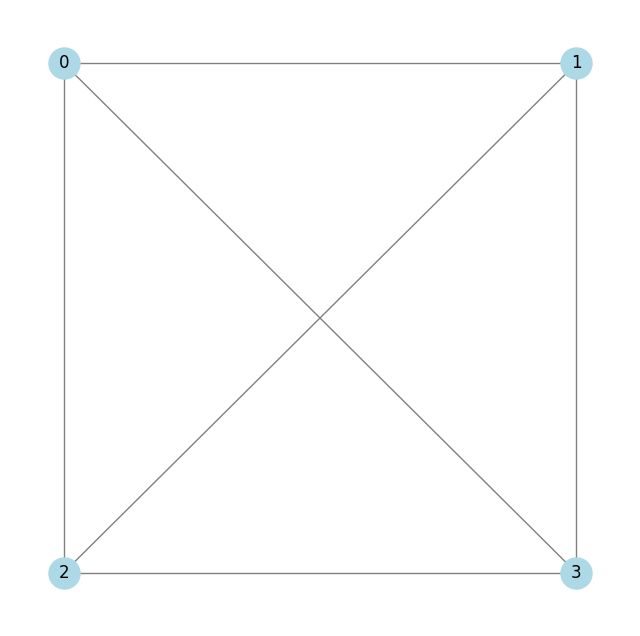

In [36]:
# Plot routes chosen by the solver
fig, ax = plt.subplots(figsize=(8,8))
nx.draw(g, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=500, ax=ax)
ax.scatter(pos[depot][0], pos[depot][1], color='green', s=100, label='Depot', marker='X')
for k_idx, k in enumerate(buses):
    pass
    # selected_arcs_k = [arcs[i] for i in range(A) if x[i, k_idx].value > 0.5]
    # for arc in selected_arcs_k:
    #     i, j = arc
    #     ax.plot([pos[i][0], pos[j][0]], [pos[i][1], pos[j][1]], color='red', linewidth=2, marker=">", markersize=10)